# N06 - Application: Three-Level Quantum Mixers
## Two quantized modes, signed detunings, Raman conversion, and pair processes

A three-level atom coupled to two quantized modes is an elementary quantum mixer. The microscopic topology selects which atomic operator products survive, while the signs of the detunings select whether the slow second-order beat is a difference or a sum.

$$
\boxed{
\text{topology selects the operator sector, and signed detunings select the resonance sector.}
}
$$

The numerical examples use QuTiP 5 for Hilbert-space construction, operator algebra, dynamics, and state diagnostics. Compact invariant-sector Hamiltonians are used only where the excitation invariant makes them exact representations of the selected physical sector.


## 1. Motivation and applications

Three-level systems support Raman transitions, electromagnetically induced transparency, and stimulated Raman adiabatic passage. These processes organize coherent control through virtual excitation and interference [Fleischhauer, Imamoglu, and Marangos (2005)](https://doi.org/10.1103/RevModPhys.77.633) and [Vitanov *et al.* (2017)](https://doi.org/10.1103/RevModPhys.89.015006).

When both fields are quantized, a Raman event also changes photon numbers. The effective interaction couples an atomic transition to a field monomial such as $a^\dagger b$, $ab$, or $a^\dagger b^\dagger$. This produces conditional frequency conversion, collapse-revival dynamics, atom-field entanglement, and correlated two-photon processes [Gerry and Eberly (1990)](https://doi.org/10.1103/PhysRevA.42.6805), [Alexanian and Bose (1995)](https://doi.org/10.1103/PhysRevA.52.2218), and [Wu (1996)](https://doi.org/10.1103/PhysRevA.54.1586).

The same structure appears in cavity Raman control [Boozer (2008)](https://doi.org/10.1103/PhysRevA.78.033406), driven resonator exchange and squeezing [Serra *et al.* (2005)](https://doi.org/10.1103/PhysRevA.71.045802) and [Prado *et al.* (2006)](https://doi.org/10.1103/PhysRevA.73.043803), tunable microwave-cavity coupling [Zhang *et al.* (2019)](https://doi.org/10.1103/PhysRevA.99.012314), cyclic artificial-atom wave mixing [Liu *et al.* (2014)](https://doi.org/10.1038/srep07289) and [Hönigl-Decrinis *et al.* (2018)](https://doi.org/10.1103/PhysRevA.98.041801), and dark-state quantum-light generation [Villas-Boas *et al.* (2020)](https://doi.org/10.1103/PhysRevLett.124.093603).

## 2. Physical setting and learning goals

The three standard topologies are

$$
\Lambda:\ |1\rangle\leftrightarrow|3\rangle\leftrightarrow|2\rangle,
\qquad
V:\ |2\rangle\leftrightarrow|1\rangle\leftrightarrow|3\rangle,
\qquad
\Xi:\ |1\rangle\leftrightarrow|2\rangle\leftrightarrow|3\rangle.
$$

The calculations below establish:

1. the complete second-order Stark and conversion sectors for all three topologies;
2. the difference resonance of the $\Lambda$ and $V$ systems and the sum resonance of the ladder system;
3. equivalence of James-Jerke averaging and the small-rotation construction at second order;
4. exact-versus-effective dynamics in the full atom and two-mode field Hilbert space;
5. intermediate-level leakage and physical-frame reconstruction;
6. bare-versus-Stark-corrected resonance positions;
7. perturbative error scaling, Fock-sector dependence, and cutoff convergence;
8. the controlled degenerate-mode limit that produces conditional single-mode squeezing.


## 3. Claim-diagnostic map

| Physical claim | Initial state | Primary observable | Validity diagnostic |
|---|---|---|---|
| $\Lambda$ Raman conversion | $|1;1,0\rangle$ | $P_{|2;0,1\rangle}$ | intermediate-level leakage and endpoint trace distance |
| $V$ upper-manifold conversion | $|2;0,1\rangle$ | $P_{|3;1,0\rangle}$ | lower-state leakage and atom-field entropy |
| $\Xi$ pair emission | $|3;0,0\rangle$ | $P_{|1;1,1\rangle}$ | intermediate-level leakage and mode-number balance |
| Stark-corrected resonance | detuning scan | maximum endpoint transfer | exact and complete-effective peak positions |
| Physical-frame reconstruction | bare endpoint state | virtual-level population | improvement after the fast initial layer is restored |
| Perturbative validity | coupling and Fock scans | spectral and dynamical error | fourth-order energy error and leakage growth |
| Algebraic consistency | finite tensor-product space | commutator residuals | safe-subspace residual and excitation invariant |


## 4. Model and signed-detuning convention

Let

$$
\sigma_{ij}=|i\rangle\langle j|,
\qquad
H_0=\sum_{j=1}^3 E_j\sigma_{jj}+\omega_a a^\dagger a+\omega_b b^\dagger b.
$$

For a transition $|j\rangle\rightarrow|i\rangle$ with $E_i>E_j$,

$$
V_{ij}^{(a)}=g_a a\sigma_{ij}+g_a^*a^\dagger\sigma_{ji}.
$$

The signed detuning is

$$
\Delta_{ij}^{(a)}=\omega_a-\omega_{ij},
\qquad
\omega_{ij}=E_i-E_j.
$$

Thus $g_a a\sigma_{ij}$ carries $e^{-i\Delta_{ij}^{(a)}t}$ in the interaction picture. Equal-sign detunings support a slow difference beat, while opposite-sign detunings support a slow sum beat after the negative-frequency harmonic is canonicalized.


## 5. Second-order constructions

Write

$$
H_I(t)=\sum_j\left(h_j e^{-i\Delta_jt}+h_j^\dagger e^{i\Delta_jt}\right).
$$

For James-Jerke averaging [James and Jerke (2007)](https://doi.org/10.1139/P07-060), define positive frequencies $\omega_j=|\Delta_j|$ and canonical operators

$$
\widetilde h_j=
\begin{cases}
h_j,&\Delta_j>0,\\
h_j^\dagger,&\Delta_j<0.
\end{cases}
$$

The slowly varying second-order Hamiltonian is

$$
H_{\mathrm{JJ}}^{(2)}(t)=
\sum_{m,n}
\frac{[\widetilde h_m^\dagger,\widetilde h_n]}
{\overline\omega_{mn}}
 e^{i(\omega_m-\omega_n)t},
\qquad
\frac{1}{\overline\omega_{mn}}=
\frac12\left(\frac1{\omega_m}+\frac1{\omega_n}\right).
$$

The small-rotation construction [Klimov and Sánchez-Soto (2000)](https://doi.org/10.1103/PhysRevA.61.063802) uses

$$
G=\sum_n\frac{h_n^\dagger-h_n}{\Delta_n},
\qquad
H_{\mathrm{rot}}=e^GHe^{-G}=H_0+\frac12[G,V]+O(g^3/\Delta^2).
$$

The rotation also reconstructs physical states and observables. A symmetrized projection [Brion, Pedersen, and Mølmer (2007)](https://doi.org/10.1088/1751-8113/40/5/011) provides the same endpoint matrix element,

$$
\langle\alpha|H_{\mathrm{proj}}^{(2)}|\beta\rangle
=\frac12\sum_{\mu\in Q}
\langle\alpha|V|\mu\rangle\langle\mu|V|\beta\rangle
\left[
\frac1{E_\alpha-E_\mu}+\frac1{E_\beta-E_\mu}
\right].
$$


## 6. Numerical setup

QuTiP constructs the atomic and field operators, preserves the tensor-product dimensions, propagates the exact and effective models, and evaluates the quantum-state diagnostics. SciPy is used only for the scalar root that locates the Stark-corrected resonance.


In [22]:
from pathlib import Path
import json
import logging
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import qutip as qt
from qutip import (
    basis, commutator, destroy, entropy_vn, expect, fidelity,
    ket2dm, qeye, sesolve, tensor, tracedist,
)

version = tuple(int(x) for x in qt.__version__.split('.')[:2])
if version < (5, 2):
    raise RuntimeError(f"N06 requires QuTiP 5.2 or newer; found {qt.__version__}.")

import scienceplots  # noqa: F401

plt.style.use(["science", "notebook"])
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

ROOT = Path.cwd()
FIG_ROOT = ROOT / "figures"
FIG_MANUSCRIPT = FIG_ROOT / "manuscript"
FIG_NOTEBOOK = FIG_ROOT / "notebook"
FIG = FIG_NOTEBOOK
DATA = ROOT / "data"
for directory in (FIG_MANUSCRIPT, FIG_NOTEBOOK, DATA):
    directory.mkdir(parents=True, exist_ok=True)
DATA.mkdir(exist_ok=True)

# Match the manuscript plotting style used in the reference notebook.
# 150 mm is the required physical figure width.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    # Render both text and mathematics with LaTeX.
    "text.usetex": True,
    "font.family": "serif",
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,

    # Line/axis styling.
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,
    "legend.frameon": False,

    "text.latex.preamble": r"\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

OPT = {
    "method": "vern9",
    "atol": 1e-10,
    "rtol": 1e-10,
    "nsteps": 100000,
    "store_states": True,
    "progress_bar": "",
}

Na = 4
Nb = 4
I3, Ia, Ib = qeye(3), qeye(Na), qeye(Nb)
Id = tensor(I3, Ia, Ib)


def sig(i, j):
    """Atomic |i><j| with labels i,j in {1,2,3}."""
    return basis(3, i - 1) * basis(3, j - 1).dag()


def S(i, j):
    return tensor(sig(i, j), Ia, Ib)


def ket(i, na, nb):
    return tensor(basis(3, i - 1), basis(Na, na), basis(Nb, nb))


def save(fig, name, manuscript=False):
    directory = FIG_MANUSCRIPT if manuscript else FIG_NOTEBOOK
    # Do not use bbox_inches="tight": it changes the physical PDF width.
    # The canvas itself is fixed to exactly 150 mm by FIG_WIDTH_150MM.
    fig.savefig(
        directory / f"{name}.pdf",
        dpi=600,
        metadata={"Creator": "QuTiP N06"},
    )
    fig.savefig(directory / f"{name}.png", dpi=600)


def solve(H, psi0, t, ops=()):
    return sesolve(H, psi0, np.asarray(t, dtype=float), e_ops=list(ops), options=OPT)


def endpoint_metrics(exact, effective, P):
    projected = P * exact
    if projected.norm() < 1e-14:
        return np.nan, np.nan
    rho = ket2dm(projected.unit())
    sigma = ket2dm(effective)
    return fidelity(rho, sigma), tracedist(rho, sigma)


a = tensor(I3, destroy(Na), Ib)
b = tensor(I3, Ia, destroy(Nb))
na = a.dag() * a
nb = b.dag() * b
P1, P2, P3 = S(1, 1), S(2, 2), S(3, 3)

print(f"Python {sys.version.split()[0]}")
print(f"QuTiP {qt.__version__}")
print(f"Composite dimensions: {a.dims}")


Python 3.11.9
QuTiP 5.2.0
Composite dimensions: [[3, 4, 4], [3, 4, 4]]


## Manuscript topology map

The following code generates the article schematic. It separates the three atomic topologies from the signed-detuning rule that selects frequency conversion or correlated pair processes.

In [23]:
from hashlib import sha256
from pathlib import Path

asset_pdf = Path("assets/manuscript/N06_MF1.pdf")
asset_png = Path("assets/manuscript/N06_MF1.png")
target_dir = Path("figures/manuscript")
target_pdf = target_dir / "N06_MF1.pdf"

hash_pdf = sha256(asset_pdf.read_bytes()).hexdigest()
hash_png = sha256(asset_png.read_bytes()).hexdigest()
hash_target = sha256(target_pdf.read_bytes()).hexdigest()
print(hash_pdf)
print(hash_png)
print(hash_target)

79dc5d882ed0e3e9ac4863507d3037462083c95ca743c0acbbbb99b1cfc0f50e
01a02593f19f5867eda019dfb77acb757db56101423dd69872158570cd754fd6
79dc5d882ed0e3e9ac4863507d3037462083c95ca743c0acbbbb99b1cfc0f50e


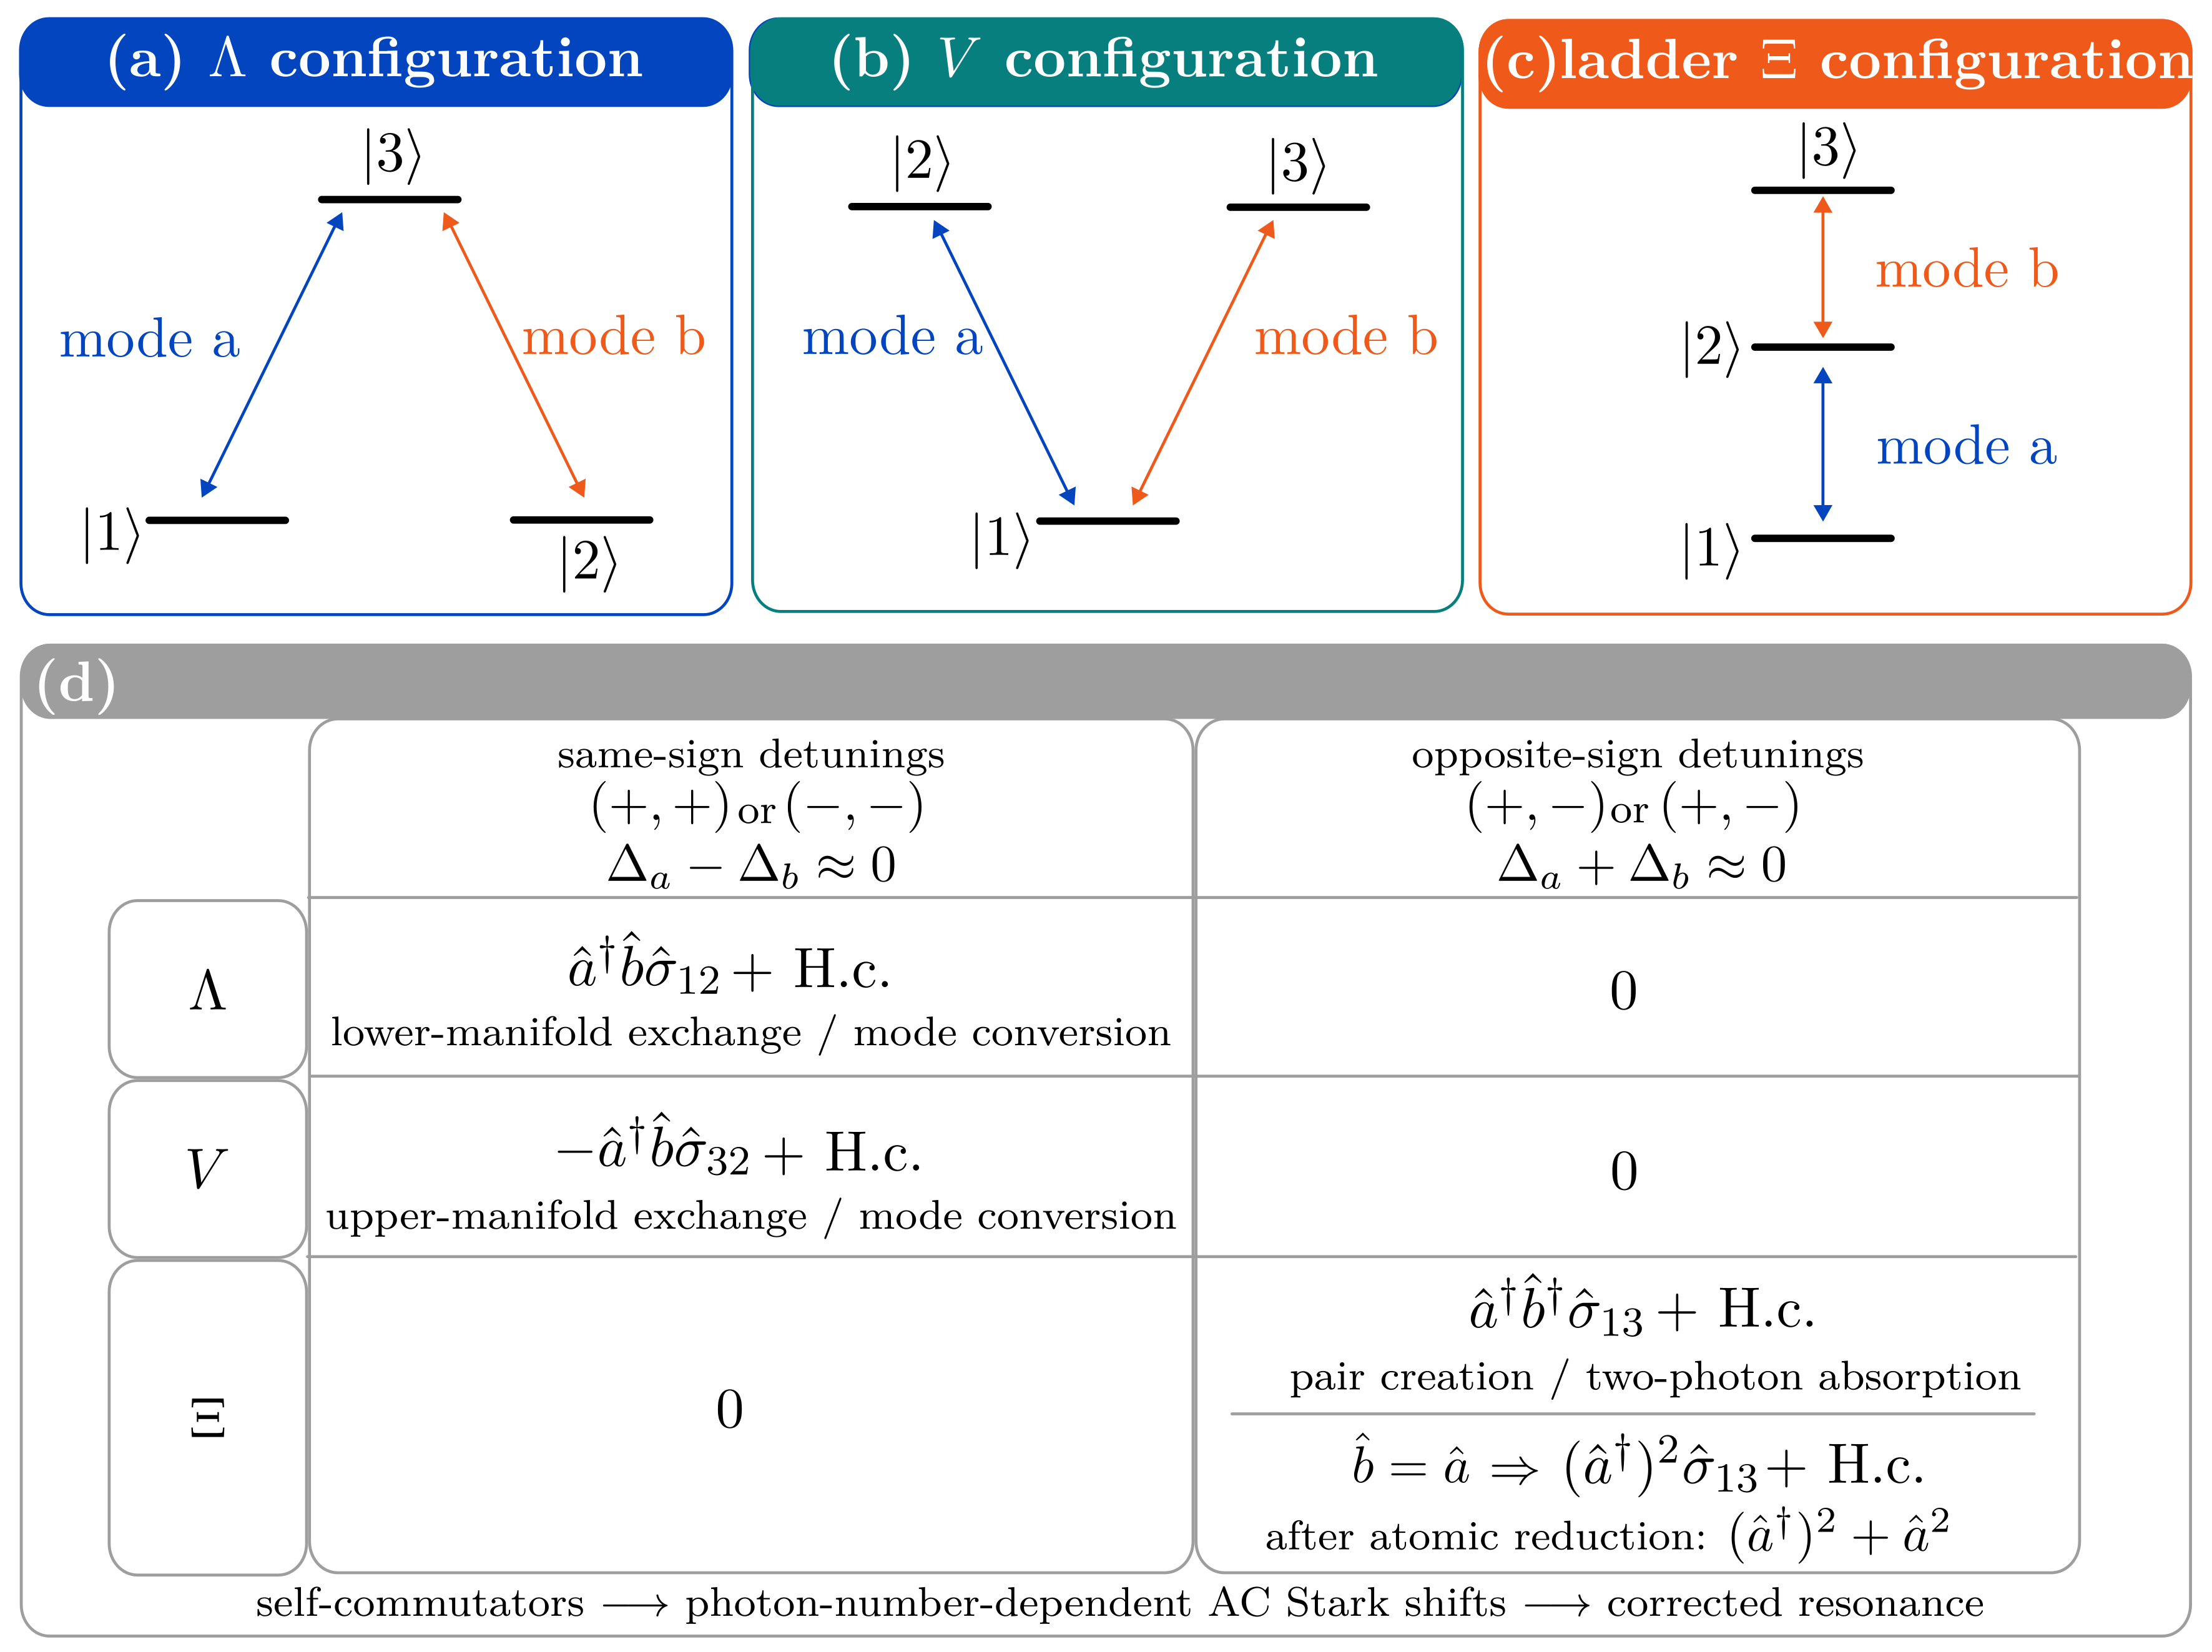

In [24]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N06_MF1.pdf")
asset_png = Path("assets/manuscript/N06_MF1.png")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N06_MF1.pdf"
target_png = target_dir / "N06_MF1.png"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_png, target_png)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "79dc5d882ed0e3e9ac4863507d3037462083c95ca743c0acbbbb99b1cfc0f50e"
assert sha256(target_pdf.read_bytes()).hexdigest() == "79dc5d882ed0e3e9ac4863507d3037462083c95ca743c0acbbbb99b1cfc0f50e"
display(Image(filename=str(target_png), width=920))

**Manuscript Figure N06_MF1. Three-level quantum mixers.**
The $\Lambda$, $V$, and $\Xi$ topologies select different atomic operator products. Equal-sign detunings retain a difference-frequency conversion term, while opposite-sign detunings retain a sum-frequency pair term after canonicalization of the negative-frequency harmonic.

## 7. Operator algebra and exact excitation invariants

Define

$$
\begin{array}{lll}
\Lambda:&h_a=g_a a\sigma_{31},&h_b=g_b b\sigma_{32},\\
V:&h_a=g_a a\sigma_{21},&h_b=g_b b\sigma_{31},\\
\Xi:&h_a=g_a a\sigma_{21},&h_b=g_b b\sigma_{32}.
\end{array}
$$

The rotating-wave microscopic Hamiltonians conserve

$$
N_\Lambda=n_a+n_b+\sigma_{33},
$$

$$
N_V=n_a+n_b+\sigma_{22}+\sigma_{33},
$$

and

$$
N_\Xi=n_a+n_b+\sigma_{22}+2\sigma_{33}.
$$

A truncated oscillator violates $[a,a^\dagger]=1$ only at its upper boundary. The residuals below are therefore evaluated after projecting away the highest Fock state of each mode.


In [25]:
g0, h0 = 0.37, 0.29

ha_L = g0 * a * S(3, 1)
hb_L = h0 * b * S(3, 2)
ha_V = g0 * a * S(2, 1)
hb_V = h0 * b * S(3, 1)
ha_X = g0 * a * S(2, 1)
hb_X = h0 * b * S(3, 2)

Pfa = sum((basis(Na, n).proj() for n in range(Na - 1)), 0 * Ia)
Pfb = sum((basis(Nb, n).proj() for n in range(Nb - 1)), 0 * Ib)
Psafe = tensor(I3, Pfa, Pfb)


def residual(lhs, rhs):
    return (Psafe * (lhs - rhs) * Psafe).norm("fro")

Laa = g0**2 * (na * P1 - (na + Id) * P3)
Lbb = h0**2 * (nb * P2 - (nb + Id) * P3)
Lab = g0 * h0 * a.dag() * b * S(1, 2)

Vaa = g0**2 * (na * P1 - (na + Id) * P2)
Vbb = h0**2 * (nb * P1 - (nb + Id) * P3)
Vab = -g0 * h0 * a.dag() * b * S(3, 2)

Xaa = g0**2 * (na * P1 - (na + Id) * P2)
Xbb = h0**2 * (nb * P2 - (nb + Id) * P3)
Xab = g0 * h0 * a.dag() * b.dag() * S(1, 3)

C = pd.DataFrame([
    ("Lambda", "[ha.dag(),ha]", residual(commutator(ha_L.dag(), ha_L), Laa)),
    ("Lambda", "[hb.dag(),hb]", residual(commutator(hb_L.dag(), hb_L), Lbb)),
    ("Lambda", "[ha.dag(),hb]", residual(commutator(ha_L.dag(), hb_L), Lab)),
    ("V", "[ha.dag(),ha]", residual(commutator(ha_V.dag(), ha_V), Vaa)),
    ("V", "[hb.dag(),hb]", residual(commutator(hb_V.dag(), hb_V), Vbb)),
    ("V", "[ha.dag(),hb]", residual(commutator(ha_V.dag(), hb_V), Vab)),
    ("Xi", "[ha.dag(),ha]", residual(commutator(ha_X.dag(), ha_X), Xaa)),
    ("Xi", "[hb.dag(),hb]", residual(commutator(hb_X.dag(), hb_X), Xbb)),
    ("Xi", "[ha.dag(),hb.dag()]", residual(commutator(ha_X.dag(), hb_X.dag()), Xab)),
], columns=["topology", "identity", "residual"])

HL0 = ha_L + ha_L.dag() + hb_L + hb_L.dag()
HV0 = ha_V + ha_V.dag() + hb_V + hb_V.dag()
HX0 = ha_X + ha_X.dag() + hb_X + hb_X.dag()
NL = na + nb + P3
NV = na + nb + P2 + P3
NX = na + nb + P2 + 2 * P3

I = pd.DataFrame([
    ("Lambda", residual(commutator(HL0, NL), 0 * Id)),
    ("V", residual(commutator(HV0, NV), 0 * Id)),
    ("Xi", residual(commutator(HX0, NX), 0 * Id)),
], columns=["topology", "norm_[H,N]"])

C.to_csv(DATA / "N06_D1.csv", index=False)
I.to_csv(DATA / "N06_D2.csv", index=False)
display(C)
display(I)


,topology,identity,residual
0,Lambda,"[ha.dag(),ha]",0.0
1,Lambda,"[hb.dag(),hb]",0.0
2,Lambda,"[ha.dag(),hb]",0.0
3,V,"[ha.dag(),ha]",0.0
4,V,"[hb.dag(),hb]",0.0
5,V,"[ha.dag(),hb]",0.0
6,Xi,"[ha.dag(),ha]",0.0
7,Xi,"[hb.dag(),hb]",0.0
8,Xi,"[ha.dag(),hb.dag()]",0.0


,topology,"norm_[H,N]"
0,Lambda,0.0
1,V,0.0
2,Xi,0.0


## 8. Effective operator sectors

For the $\Lambda$ system,

$$
[h_a^\dagger,h_b]=g_a^*g_b a^\dagger b\sigma_{12},
$$

so the cross term converts a $b$ photon into an $a$ photon while transferring the atom between the lower states. The complete second-order Hamiltonian is

$$
\begin{aligned}
H_{\mathrm{eff}}^{(\Lambda)}={}&
\frac{|g_a|^2}{\Delta_a}\left[n_a\sigma_{11}-(n_a+1)\sigma_{33}\right]
+\frac{|g_b|^2}{\Delta_b}\left[n_b\sigma_{22}-(n_b+1)\sigma_{33}\right]\\
&+\frac{g_a^*g_b}{2}\left(\frac1{\Delta_a}+\frac1{\Delta_b}\right)
 a^\dagger b\sigma_{12}e^{i(\Delta_a-\Delta_b)t}+\mathrm{H.c.}
\end{aligned}
$$

For the $V$ system,

$$
[h_a^\dagger,h_b]=-g_a^*g_b a^\dagger b\sigma_{32},
$$

which gives the corresponding upper-manifold Raman conversion with the opposite operator sign.

For the ladder system with $\Delta_a>0$ and $\Delta_b<0$,

$$
[h_a^\dagger,h_b^\dagger]=g_a^*g_b^*a^\dagger b^\dagger\sigma_{13},
$$

and the slow phase is $e^{i(\Delta_a+\Delta_b)t}$. The ladder therefore generates correlated pair emission or two-photon absorption.


## 9. James-Jerke and small-rotation equivalence

The second-order term obtained from the rotation is $[G,V]/2$. The next cell compares it directly with the complete James-Jerke operator for all three topologies. The comparison is performed on QuTiP `Qobj` operators and restricted only to the cutoff-safe Fock subspace.


In [26]:
Da, Db_same, Db_opp = 6.0, 7.0, -7.0


def rotation_check(ha, hb, Db, expected):
    V = ha + ha.dag() + hb + hb.dag()
    G = (ha.dag() - ha) / Da + (hb.dag() - hb) / Db
    return residual(0.5 * commutator(G, V), expected)

chi_same = 0.5 * (1 / Da + 1 / Db_same)
chi_pair = 0.5 * (1 / Da - 1 / Db_opp)

EL = Laa / Da + Lbb / Db_same + chi_same * (Lab + Lab.dag())
EV = Vaa / Da + Vbb / Db_same + chi_same * (Vab + Vab.dag())
EX = Xaa / Da + Xbb / Db_opp + chi_pair * (Xab + Xab.dag())

M = pd.DataFrame([
    ("Lambda", rotation_check(ha_L, hb_L, Db_same, EL)),
    ("V", rotation_check(ha_V, hb_V, Db_same, EV)),
    ("Xi", rotation_check(ha_X, hb_X, Db_opp, EX)),
], columns=["topology", "rotation_residual"])
M.to_csv(DATA / "N06_D3.csv", index=False)
display(M)


,topology,rotation_residual
0,Lambda,0.0
1,V,0.0
2,Xi,0.0


## 10. Full QuTiP models and effective endpoint Hamiltonians

The rotating-frame Hamiltonians are constructed in the full tensor-product space. For the selected states, the excitation invariants restrict the exact dynamics to a three-state sector, but the numerical implementation retains the atom and both field modes explicitly.


In [27]:
# Lambda states: |1;1,0> <-> |3;0,0> <-> |2;0,1>
AL, IL, BL = ket(1, 1, 0), ket(3, 0, 0), ket(2, 0, 1)
PAL, PIL, PBL = AL.proj(), IL.proj(), BL.proj()
PEL = PAL + PBL

# V states: |2;0,1> <-> |1;1,1> <-> |3;1,0>
AV, IV, BV = ket(2, 0, 1), ket(1, 1, 1), ket(3, 1, 0)
PAV, PIV, PBV = AV.proj(), IV.proj(), BV.proj()
PEV = PAV + PBV

# Xi states: |1;1,1> <-> |2;0,1> <-> |3;0,0>
GX, IX, EX = ket(1, 1, 1), ket(2, 0, 1), ket(3, 0, 0)
PGX, PIX, PEX = GX.proj(), IX.proj(), EX.proj()
PEXi = PGX + PEX


def lambda_model(delta, Da=8.0, ga=0.50, gb=0.36):
    Db = Da - delta
    J = 0.5 * ga * gb * (1 / Da + 1 / Db)
    H = -Da * P3 - delta * P2 + ga * (a * S(3, 1) + a.dag() * S(1, 3)) \
        + gb * (b * S(3, 2) + b.dag() * S(2, 3))
    He = (ga**2 / Da) * PAL + (-delta + gb**2 / Db) * PBL \
        + J * (AL * BL.dag() + BL * AL.dag())
    Hx = -delta * PBL + J * (AL * BL.dag() + BL * AL.dag())
    return H, He, Hx, Db, J


def v_model(delta, Da=8.0, ga=0.42, gb=0.31):
    Db = Da - delta
    J = 0.5 * ga * gb * (1 / Da + 1 / Db)
    H = Da * P1 + delta * P3 + ga * (a * S(2, 1) + a.dag() * S(1, 2)) \
        + gb * (b * S(3, 1) + b.dag() * S(1, 3))
    He = (-ga**2 / Da) * PAV + (delta - gb**2 / Db) * PBV \
        - J * (AV * BV.dag() + BV * AV.dag())
    return H, He, Db, -J


def xi_model(delta, Da=8.0, ga=0.35, gb=0.35):
    Db = delta - Da
    J = 0.5 * ga * gb * (1 / Da - 1 / Db)
    H = -Da * P2 - delta * P3 + ga * (a * S(2, 1) + a.dag() * S(1, 2)) \
        + gb * (b * S(3, 2) + b.dag() * S(2, 3))
    He = (ga**2 / Da) * PGX + (-delta - gb**2 / Db) * PEX \
        + J * (GX * EX.dag() + EX * GX.dag())
    Hx = -delta * PEX + J * (GX * EX.dag() + EX * GX.dag())
    return H, He, Hx, Db, J


## 11. $\Lambda$ benchmark and physical-frame diagnostics

The Stark-corrected two-photon resonance satisfies

$$
\delta_\Lambda=
\frac{g_b^2}{\Delta_b}-\frac{g_a^2}{\Delta_a},
\qquad
\Delta_b=\Delta_a-\delta_\Lambda.
$$

The exact dynamics is compared with the complete second-order endpoint Hamiltonian. In addition to transfer and leakage, the calculation records endpoint trace distance and the entropy of the reduced atomic state.


### 10.1 Bright and dark endpoint combinations

For the resonant three-state chain, only one endpoint superposition couples to the intermediate level. With $\Omega=(\lvert g_a\rvert^2+\lvert g_b\rvert^2)^{1/2}$,
$$
\lvert C\rangle=\frac{g_a\lvert A\rangle+g_b\lvert B\rangle}{\Omega},\qquad
\lvert D\rangle=\frac{g_b\lvert A\rangle-g_a\lvert B\rangle}{\Omega}.
$$
The coupled state $\lvert C\rangle$ connects to $\lvert I\rangle$ with matrix element $\Omega$, whereas $\lvert D\rangle$ is dark. This basis exposes the interference behind Raman transfer before any elimination is performed.

In [28]:
ga_bright, gb_bright = 0.50, 0.36
Omega_L = np.sqrt(ga_bright**2 + gb_bright**2)
bright_L = (ga_bright * AL + gb_bright * BL).unit()
dark_L = (gb_bright * AL - ga_bright * BL).unit()
V_L = ga_bright * (IL * AL.dag() + AL * IL.dag()) + gb_bright * (IL * BL.dag() + BL * IL.dag())
bright_dark = pd.DataFrame({
    "check": ["dark_coupling_norm", "bright_coupling", "bright_dark_overlap"],
    "value": [
        float((V_L * dark_L).norm()),
        float(abs(IL.overlap(V_L * bright_L))),
        float(abs(bright_L.overlap(dark_L))),
    ],
    "expected": [0.0, float(Omega_L), 0.0],
})
bright_dark.to_csv(DATA / "N06_D17.csv", index=False)
assert bright_dark.loc[0, "value"] < 1e-12
assert abs(bright_dark.loc[1, "value"] - Omega_L) < 1e-12
display(bright_dark)

,check,value,expected
0,dark_coupling_norm,0.000000,0.000000
1,bright_coupling,0.616117,0.616117
2,bright_dark_overlap,0.000000,0.000000


In [29]:
DaL, gaL, gbL = 8.0, 0.50, 0.36
fL = lambda d: d - (gbL**2 / (DaL - d) - gaL**2 / DaL)
dL = brentq(fL, -0.08, 0.05)
HL, HLe, HLx, DbL, JL = lambda_model(dL, DaL, gaL, gbL)
tL = np.linspace(0, 1.35 * np.pi / (2 * abs(JL)), 1001)

rL = solve(HL, AL, tL, (PAL, PIL, PBL))
eL = solve(HLe, AL, tL, (PBL,))
PLA, PLI, PLB = [np.real(np.asarray(x)) for x in rL.expect]
PLBe = np.real(np.asarray(eL.expect[0]))
FL, TDL = zip(*(endpoint_metrics(x, y, PEL) for x, y in zip(rL.states, eL.states)))
FL = np.asarray(FL, dtype=float)
TDL = np.asarray(TDL, dtype=float)
SAL = np.asarray([entropy_vn(ket2dm(x).ptrace(0), base=2) for x in rL.states])

lambda_summary = {
    "delta_corrected": float(dL),
    "Delta_b": float(DbL),
    "J": float(JL),
    "max_transfer_exact": float(PLB.max()),
    "max_transfer_effective": float(PLBe.max()),
    "max_leakage": float(PLI.max()),
    "minimum_endpoint_fidelity": float(np.nanmin(FL)),
    "max_endpoint_trace_distance": float(np.nanmax(TDL)),
    "max_atomic_entropy_bits": float(SAL.max()),
}

pd.DataFrame({
    "t": tL, "P_A": PLA, "P_I": PLI, "P_B": PLB,
    "P_B_eff": PLBe, "fidelity": FL, "trace_distance": TDL, "S_atom": SAL,
}).to_csv(DATA / "N06_D4.csv", index=False)
lambda_summary


C:\Users\quant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


{'delta_corrected': -0.015080480515441367,
 'Delta_b': 8.015080480515442,
 'J': 0.022478832975387938,
 'max_transfer_exact': 0.9995772306313772,
 'max_transfer_effective': 0.9999996977433967,
 'max_leakage': 0.015238845132298852,
 'minimum_endpoint_fidelity': 0.9998568075426335,
 'max_endpoint_trace_distance': 0.016922305122326495,
 'max_atomic_entropy_bits': 1.0885989445341182}

## 12. Reconstructing the virtual intermediate level

The slow endpoint model contains no explicit intermediate state. The small rotation reconstructs the dressed physical state,

$$
|\psi\rangle_{\mathrm{phys}}\simeq e^{-G}|\psi\rangle_{\mathrm{eff}}.
$$

For a suddenly prepared bare endpoint state, slow dressing alone produces an unphysical nonzero intermediate amplitude at $t=0$. The rapidly oscillating initial layer restores the bare initial condition. Both reconstructions are compared with the exact QuTiP trajectory.


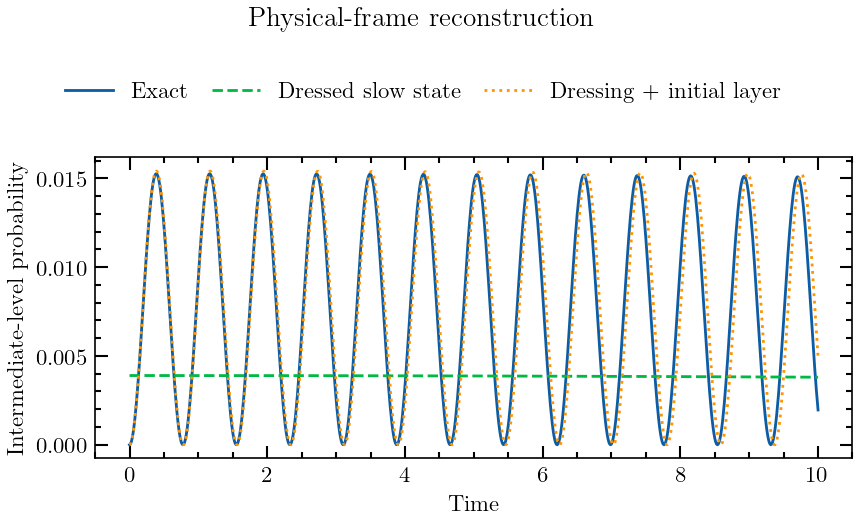

{'rmse_slow': 0.006563523542038158,
 'rmse_with_initial_layer': 0.0014685830224336464,
 'max_error_slow': 0.011364450334976555,
 'max_error_with_initial_layer': 0.003622338975618894}

In [30]:
tR = np.linspace(0, 10, 801)
rR = solve(HL, AL, tR)
eR = solve(HLe, AL, tR)

ha = gaL * a * S(3, 1)
hb = gbL * b * S(3, 2)
Grot = (ha.dag() - ha) / DaL + (hb.dag() - hb) / DbL
Uback = (-Grot).expm()

dressed = [(Uback * x).unit() for x in eR.states]
PI_slow = np.asarray([expect(PIL, x) for x in dressed], dtype=float)
PI_exact = np.asarray([expect(PIL, x) for x in rR.states], dtype=float)

c0 = IL.overlap(dressed[0])
complete = []
for t, x in zip(tR, dressed):
    y = x - c0 * np.exp(1j * DaL * t) * IL
    complete.append(y.unit())
PI_full = np.asarray([expect(PIL, x) for x in complete], dtype=float)

reconstruction = {
    "rmse_slow": float(np.sqrt(np.mean((PI_slow - PI_exact)**2))),
    "rmse_with_initial_layer": float(np.sqrt(np.mean((PI_full - PI_exact)**2))),
    "max_error_slow": float(np.max(np.abs(PI_slow - PI_exact))),
    "max_error_with_initial_layer": float(np.max(np.abs(PI_full - PI_exact))),
}

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.65))
fig.subplots_adjust(left=0.13, right=0.985, bottom=0.15, top=0.70)
ax.plot(tR, PI_exact, label="Exact")
ax.plot(tR, PI_slow, "--", label="Dressed slow state")
ax.plot(tR, PI_full, ":", label="Dressing + initial layer")
ax.set(xlabel="Time", ylabel="Intermediate-level probability")
fig.suptitle("Physical-frame reconstruction", y=0.975)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels, frameon=False, loc="upper center",
    bbox_to_anchor=(0.5, 0.875), ncol=3,
    handlelength=2.1, columnspacing=1.0,
)
save(fig, "N06_F2")
plt.show()
plt.close(fig)

pd.DataFrame({"t": tR, "exact": PI_exact, "slow": PI_slow, "complete": PI_full}).to_csv(DATA / "N06_D5.csv", index=False)
reconstruction


**Figure N06_F2. Physical-frame reconstruction.** The endpoint-only effective state reproduces the slow dressing but not the fast virtual response associated with sudden bare-state preparation. Restoring the initial layer recovers the oscillatory intermediate-level population while preserving the slow effective dynamics.


## 13. $V$ and ladder benchmarks

The $V$ system transfers population between two upper states through a virtually occupied lower state. The ladder system converts atomic excitation into a correlated photon pair. Both calculations use the full QuTiP tensor-product Hamiltonians and complete second-order endpoint models.


In [31]:
# V configuration
DaV, gaV, gbV = 8.0, 0.42, 0.31
fV = lambda d: d - (gbV**2 / (DaV - d) - gaV**2 / DaV)
dV = brentq(fV, -0.08, 0.05)
HV, HVe, DbV, JV = v_model(dV, DaV, gaV, gbV)
tV = np.linspace(0, 1.35 * np.pi / (2 * abs(JV)), 1001)
rV = solve(HV, AV, tV, (PAV, PIV, PBV))
eV = solve(HVe, AV, tV, (PBV,))
PVA, PVI, PVB = [np.real(np.asarray(x)) for x in rV.expect]
PVBe = np.real(np.asarray(eV.expect[0]))
SV = np.asarray([entropy_vn(ket2dm(x).ptrace(0), base=2) for x in rV.states])

# Xi configuration
DaX, gaX, gbX = 8.0, 0.35, 0.35
dX = 0.0
HX, HXe, HXx, DbX, JX = xi_model(dX, DaX, gaX, gbX)
tX = np.linspace(0, 1.35 * np.pi / (2 * abs(JX)), 1001)
rX = solve(HX, EX, tX, (PGX, PIX, PEX, na, nb))
eX = solve(HXe, EX, tX, (PGX,))
PXG, PXI, PXE, nXa, nXb = [np.real(np.asarray(x)) for x in rX.expect]
PXGe = np.real(np.asarray(eX.expect[0]))

v_summary = {
    "delta_corrected": float(dV),
    "J": float(JV),
    "max_transfer_exact": float(PVB.max()),
    "max_transfer_effective": float(PVBe.max()),
    "max_leakage": float(PVI.max()),
    "max_atomic_entropy_bits": float(SV.max()),
}
xi_summary = {
    "delta_sum": float(dX),
    "J": float(JX),
    "max_pair_probability_exact": float(PXG.max()),
    "max_pair_probability_effective": float(PXGe.max()),
    "max_leakage": float(PXI.max()),
    "max_mode_imbalance": float(np.max(np.abs(nXa - nXb))),
}

pd.DataFrame({"t": tV, "P_A": PVA, "P_I": PVI, "P_B": PVB, "P_B_eff": PVBe, "S_atom": SV}).to_csv(DATA / "N06_D6.csv", index=False)
pd.DataFrame({"t": tX, "P_pair": PXG, "P_I": PXI, "P_E": PXE, "P_pair_eff": PXGe, "n_a": nXa, "n_b": nXb}).to_csv(DATA / "N06_D7.csv", index=False)

v_summary, xi_summary


({'delta_corrected': -0.010052575627057142,
  'J': -0.016264787478497442,
  'max_transfer_exact': 0.999617377856417,
  'max_transfer_effective': 0.9999996977433968,
  'max_leakage': 0.010839863773484774,
  'max_atomic_entropy_bits': 1.067039005398337},
 {'delta_sum': 0.0,
  'J': 0.015312499999999998,
  'max_pair_probability_exact': 0.9999910579840972,
  'max_pair_probability_effective': 0.9999996977433959,
  'max_leakage': 0.0075407634937151155,
  'max_mode_imbalance': 0.00754076349371513})

## 14. Bare and Stark-corrected resonances

The conversion term alone predicts resonance at zero two-photon detuning. Differential Stark shifts move the actual operating point. Exact, complete-effective, and cross-only models are scanned on the same detuning axis. Compact QuTiP `Qobj` Hamiltonians are used here because each matrix is the exact representation of the conserved three-state sector.


In [32]:
def sector_max(H, start, target, tmax, points=501):
    dim = H.shape[0]
    psi0 = basis(dim, start)
    P = basis(dim, target).proj()
    t = np.linspace(0, tmax, points)
    r = sesolve(H, psi0, t, e_ops=[P], options={**OPT, "store_states": False})
    return float(np.max(np.real(r.expect[0])))


# Lambda scan
scanL = np.linspace(-0.05, 0.03, 81)
exactL, completeL, crossL = [], [], []
for d in scanL:
    Db = DaL - d
    J = 0.5 * gaL * gbL * (1 / DaL + 1 / Db)
    T = 1.25 * np.pi / (2 * abs(J))
    H3 = qt.Qobj([[0, gaL, 0], [gaL, -DaL, gbL], [0, gbL, -d]])
    H2 = qt.Qobj([[gaL**2 / DaL, J], [J, -d + gbL**2 / Db]])
    Hc = qt.Qobj([[0, J], [J, -d]])
    exactL.append(sector_max(H3, 0, 2, T))
    completeL.append(sector_max(H2, 0, 1, T))
    crossL.append(sector_max(Hc, 0, 1, T))

# Asymmetric Xi scan
DaXa, gaXa, gbXa = 8.0, 0.42, 0.28
fXa = lambda d: d + gaXa**2 / DaXa + gbXa**2 / (d - DaXa)
dXa = brentq(fXa, -0.06, 0.03)
scanX = np.linspace(-0.05, 0.03, 81)
exactX, completeX, crossX = [], [], []
for d in scanX:
    Db = d - DaXa
    J = 0.5 * gaXa * gbXa * (1 / DaXa - 1 / Db)
    T = 1.25 * np.pi / (2 * abs(J))
    H3 = qt.Qobj([[0, gaXa, 0], [gaXa, -DaXa, gbXa], [0, gbXa, -d]])
    H2 = qt.Qobj([[gaXa**2 / DaXa, J], [J, -d - gbXa**2 / Db]])
    Hc = qt.Qobj([[0, J], [J, -d]])
    exactX.append(sector_max(H3, 2, 0, T))
    completeX.append(sector_max(H2, 1, 0, T))
    crossX.append(sector_max(Hc, 1, 0, T))

resonance = {
    "lambda_prediction": float(dL),
    "lambda_exact_peak": float(scanL[np.argmax(exactL)]),
    "lambda_complete_peak": float(scanL[np.argmax(completeL)]),
    "lambda_cross_peak": float(scanL[np.argmax(crossL)]),
    "xi_prediction": float(dXa),
    "xi_exact_peak": float(scanX[np.argmax(exactX)]),
    "xi_complete_peak": float(scanX[np.argmax(completeX)]),
    "xi_cross_peak": float(scanX[np.argmax(crossX)]),
}

pd.DataFrame({"delta": scanL, "exact": exactL, "complete": completeL, "cross_only": crossL}).to_csv(DATA / "N06_D8.csv", index=False)
pd.DataFrame({"delta_sum": scanX, "exact": exactX, "complete": completeX, "cross_only": crossX}).to_csv(DATA / "N06_D9.csv", index=False)
resonance


{'lambda_prediction': -0.015080480515441367,
 'lambda_exact_peak': -0.015,
 'lambda_complete_peak': -0.015,
 'lambda_cross_peak': 0.0,
 'xi_prediction': -0.012265001627632277,
 'xi_exact_peak': -0.012000000000000004,
 'xi_complete_peak': -0.012000000000000004,
 'xi_cross_peak': 0.0}

## 15. Central comparison

The first three panels show exact and effective conversion in the full QuTiP Hilbert space. The last panel shows why the diagonal second-order terms are part of the physical prediction rather than optional corrections.


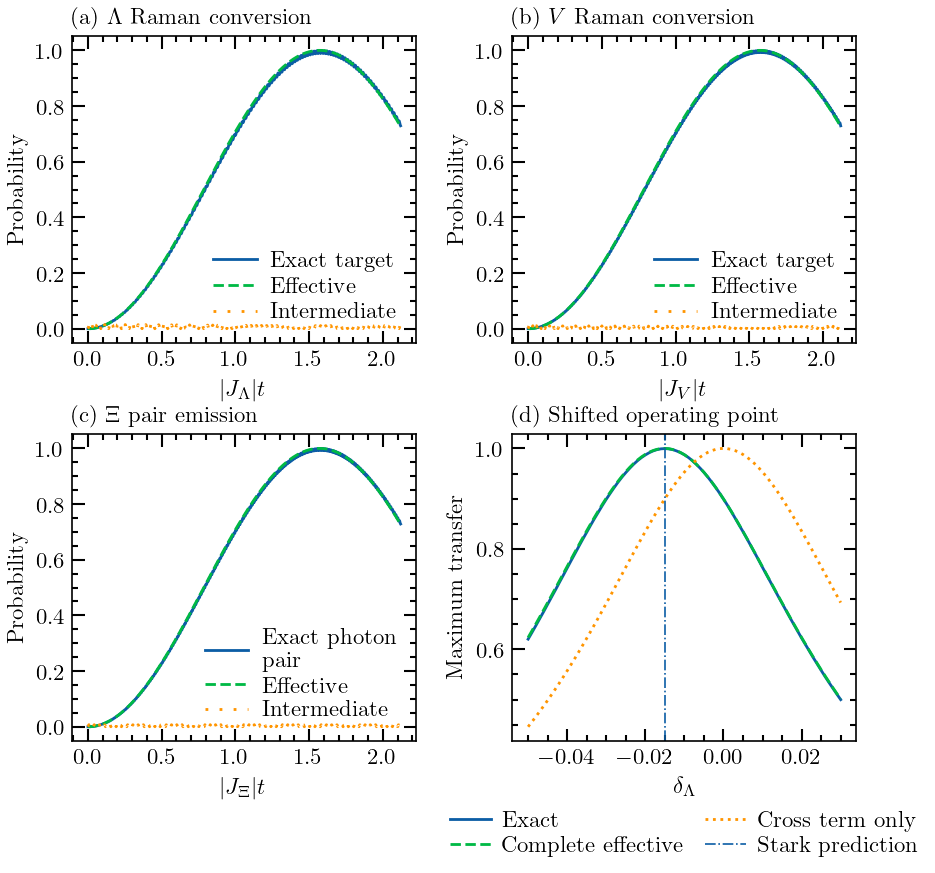

In [33]:
MM = 1 / 25.4

FIG_WIDTH  = 150 * MM   # exatamente 150 mm
FIG_HEIGHT = 150 * MM   # altura otimizada

DOT_STYLE = (0, (1.0, 4.0))

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

gs = fig.add_gridspec(
    2, 2,

    # Margens externas
    left=0.10,
    right=0.985,
    bottom=0.17,
    top=0.965,

    # Espaço entre painéis
    hspace=0.30,
    wspace=0.28,
)


# ============================================================
# (a) Lambda Raman conversion
# ============================================================

ax = fig.add_subplot(gs[0, 0])

ax.plot(tL * abs(JL), PLB, label="Exact target")
ax.plot(tL * abs(JL), PLBe, "--", label="Effective")
ax.plot(tL * abs(JL), PLI, linestyle=DOT_STYLE, label="Intermediate")

ax.set(
    xlabel=r"$|J_\Lambda|t$",
    ylabel="Probability",
)

ax.set_title(
    r"(a) $\Lambda$ Raman conversion",
    loc="left",
)

ax.legend(
    frameon=False,
    loc="lower right",
    handlelength=1.9,
    handletextpad=0.6,
    labelspacing=0.25,
    borderaxespad=0.45,
)


# ============================================================
# (b) V Raman conversion
# ============================================================

ax = fig.add_subplot(gs[0, 1])

ax.plot(tV * abs(JV), PVB, label="Exact target")
ax.plot(tV * abs(JV), PVBe, "--", label="Effective")
ax.plot(tV * abs(JV), PVI, linestyle=DOT_STYLE, label="Intermediate")

ax.set(
    xlabel=r"$|J_V|t$",
    ylabel="Probability",
)

ax.set_title(
    r"(b) $V$ Raman conversion",
    loc="left",
)

ax.legend(
    frameon=False,
    loc="lower right",
    handlelength=1.9,
    handletextpad=0.6,
    labelspacing=0.25,
    borderaxespad=0.45,
)


# ============================================================
# (c) Xi pair emission
# ============================================================

ax = fig.add_subplot(gs[1, 0])

ax.plot(
    tX * abs(JX),
    PXG,
    label="Exact photon\npair",
)

ax.plot(
    tX * abs(JX),
    PXGe,
    "--",
    label="Effective",
)

ax.plot(
    tX * abs(JX),
    PXI,
    linestyle=DOT_STYLE,
    label="Intermediate",
)

ax.set(
    xlabel=r"$|J_\Xi|t$",
    ylabel="Probability",
)

ax.set_title(
    r"(c) $\Xi$ pair emission",
    loc="left",
)

ax.legend(
    frameon=False,
    loc="lower right",
    handlelength=1.9,
    handletextpad=0.6,
    labelspacing=0.20,
    borderaxespad=0.45,
)


# ============================================================
# (d) Shifted operating point
# ============================================================

ax = fig.add_subplot(gs[1, 1])

ax.plot(
    scanL,
    exactL,
    label="Exact",
)

ax.plot(
    scanL,
    completeL,
    "--",
    label="Complete effective",
)

ax.plot(
    scanL,
    crossL,
    ":",
    label="Cross term only",
)

ax.axvline(
    dL,
    lw=0.8,
    ls="-.",
    label="Stark prediction",
)

ax.set(
    xlabel=r"$\delta_\Lambda$",
    ylabel="Maximum transfer",
)

ax.set_title(
    "(d) Shifted operating point",
    loc="left",
)


# ------------------------------------------------------------
# Legenda de (d) FORA da área dos dados
# ------------------------------------------------------------

ax.legend(
    frameon=False,

    # Centro horizontal abaixo do painel
    loc="upper center",
    bbox_to_anchor=(0.50, -0.2),

    # Duas colunas -> muito mais compacto
    ncol=2,

    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=0.9,
    labelspacing=0.20,
    borderaxespad=0.0,
)


# ============================================================
# Export
# ============================================================

save(
    fig,
    "N06_MF2",
    manuscript=True,
)

plt.show()
plt.close(fig)


**Manuscript Figure N06_MF2. Conversion sectors and shifted resonance.** Panels (a)-(c) compare exact QuTiP dynamics with the complete second-order endpoint Hamiltonians for the $\Lambda$, $V$, and $\Xi$ configurations. Panel (d) shows that the cross term alone peaks at the bare condition, whereas the diagonal Stark terms recover the shifted operating point of the full model.


## 16. Perturbative scaling, Fock sectors, and cutoff convergence

The relevant small parameter is local to the occupied Fock sector. For example,

$$
\epsilon_{\mathrm{loc}}^{(\Lambda)}=
\max\left(
\frac{|g_a|\sqrt{n_a}}{|\Delta_a|},
\frac{|g_b|\sqrt{n_b+1}}{|\Delta_b|}
\right).
$$

For the symmetric three-state spectral benchmark below, the first omitted correction to the displayed eigenvalue is fourth order, while a small frequency error can accumulate into a visible dynamical error on long times. The full tensor-product calculation is also repeated at several Fock cutoffs; the conserved sector makes the converged result independent of unused higher states.


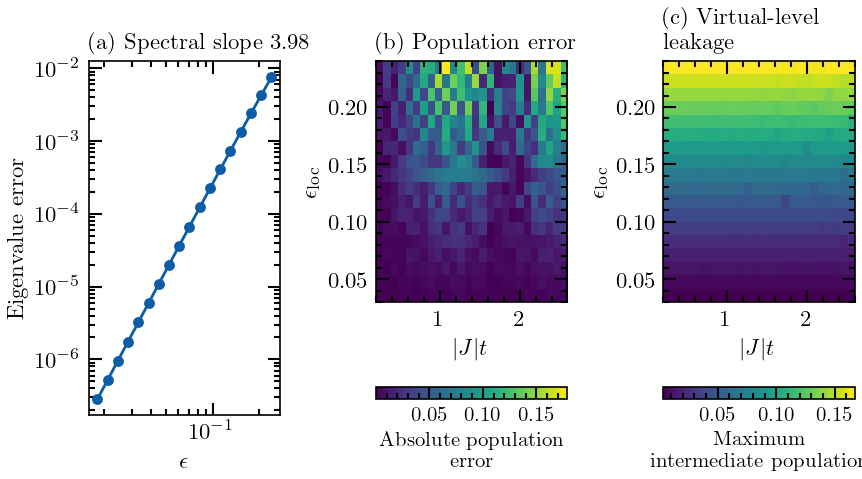

,n_a,G_a,G_b,epsilon_local,J_resonant
0,1,0.050000,0.05,0.050000,0.002500
1,2,0.070711,0.05,0.070711,0.003536
2,5,0.111803,0.05,0.111803,0.005590
3,10,0.158114,0.05,0.158114,0.007906
4,20,0.223607,0.05,0.223607,0.011180
5,40,0.316228,0.05,0.316228,0.015811


,cutoff,max_difference_from_N4
0,2,1.310063e-14
1,3,6.106227e-15
2,4,0.000000e+00


{'spectral_slope': 3.9847344683235986}

In [34]:
# Spectral scaling with QuTiP eigenenergies.
eps = np.geomspace(0.018, 0.24, 18)
err = []
for e in eps:
    ga, gb, D = e, 0.8 * e, 1.0
    H3 = qt.Qobj([[0, ga, 0], [ga, -D, gb], [0, gb, 0]])
    exact = H3.eigenenergies()[-1]
    effective = (ga**2 + gb**2) / D
    err.append(abs(exact - effective))
err = np.asarray(err)
slope = float(np.polyfit(np.log(eps[:12]), np.log(err[:12]), 1)[0])

# Dynamical breakdown map, still propagated by QuTiP.
eps_grid = np.linspace(0.03, 0.24, 18)
tau_grid = np.linspace(0.2, 2.6, 26)
Derr = np.zeros((len(eps_grid), len(tau_grid)))
Leak = np.zeros_like(Derr)
for i, e in enumerate(eps_grid):
    ga, gb, D = e, 0.8 * e, 1.0
    f = lambda d: d - (gb**2 / (D - d) - ga**2 / D)
    d = brentq(f, -0.2, 0.2)
    Db = D - d
    J = 0.5 * ga * gb * (1 / D + 1 / Db)
    H3 = qt.Qobj([[0, ga, 0], [ga, -D, gb], [0, gb, -d]])
    H2 = qt.Qobj([[ga**2 / D, J], [J, -d + gb**2 / Db]])
    for j, tau in enumerate(tau_grid):
        T = tau / abs(J)
        tt = np.linspace(0, T, 81)
        r3 = sesolve(H3, basis(3, 0), tt, e_ops=[basis(3, 1).proj(), basis(3, 2).proj()], options={**OPT, "store_states": False})
        r2 = sesolve(H2, basis(2, 0), [0, T], e_ops=[basis(2, 1).proj()], options={**OPT, "store_states": False})
        Leak[i, j] = np.max(np.real(r3.expect[0]))
        Derr[i, j] = abs(np.real(r3.expect[1][-1]) - np.real(r2.expect[0][-1]))

# Fock-sector table.
rows = []
for n in [1, 2, 5, 10, 20, 40]:
    ga = 0.05 * np.sqrt(n)
    gb = 0.05
    rows.append((n, ga, gb, max(ga, gb), ga * gb))
Fock = pd.DataFrame(rows, columns=["n_a", "G_a", "G_b", "epsilon_local", "J_resonant"])

# Full-space cutoff check.
def cutoff_curve(N):
    i3, ia, ib = qeye(3), qeye(N), qeye(N)
    aa = tensor(i3, destroy(N), ib)
    bb = tensor(i3, ia, destroy(N))
    ss = lambda i, j: tensor(sig(i, j), ia, ib)
    pp2, pp3 = ss(2, 2), ss(3, 3)
    AA = tensor(basis(3, 0), basis(N, 1), basis(N, 0))
    BB = tensor(basis(3, 1), basis(N, 0), basis(N, 1))
    HH = -DaL * pp3 - dL * pp2 + gaL * (aa * ss(3, 1) + aa.dag() * ss(1, 3)) \
        + gbL * (bb * ss(3, 2) + bb.dag() * ss(2, 3))
    rr = sesolve(HH, AA, tL, e_ops=[BB.proj()], options={**OPT, "store_states": False})
    return np.real(np.asarray(rr.expect[0]))

cut2, cut3, cut4 = cutoff_curve(2), cutoff_curve(3), cutoff_curve(4)
cutoff = pd.DataFrame([
    (2, float(np.max(np.abs(cut2 - cut4)))),
    (3, float(np.max(np.abs(cut3 - cut4)))),
    (4, 0.0),
], columns=["cutoff", "max_difference_from_N4"])

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 3.75))
gs = fig.add_gridspec(
    1, 3, left=0.11, right=0.975, bottom=0.23, top=0.86,
    wspace=0.50,
)
ax = fig.add_subplot(gs[0, 0])
ax.loglog(eps, err, "o-")
ax.set(xlabel=r"$\epsilon$", ylabel="Eigenvalue error")
ax.set_title(fr"(a) Spectral slope {slope:.2f}", loc="left")
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(Derr, origin="lower", aspect="auto", extent=[tau_grid.min(), tau_grid.max(), eps_grid.min(), eps_grid.max()])
ax.set(xlabel=r"$|J|t$", ylabel=r"$\epsilon_{\rm loc}$")
ax.set_title("(b) Population error", loc="left")
cb = fig.colorbar(
    im, ax=ax, orientation="horizontal", fraction=0.080, pad=0.24, aspect=16
)
cb.set_label("Absolute population\nerror", labelpad=3, fontsize=10.0)
cb.ax.tick_params(labelsize=10.0)
ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(Leak, origin="lower", aspect="auto", extent=[tau_grid.min(), tau_grid.max(), eps_grid.min(), eps_grid.max()])
ax.set(xlabel=r"$|J|t$", ylabel=r"$\epsilon_{\rm loc}$")
ax.set_title("(c) Virtual-level\nleakage", loc="left")
cb = fig.colorbar(
    im, ax=ax, orientation="horizontal", fraction=0.080, pad=0.24, aspect=16
)
cb.set_label("Maximum\nintermediate population", labelpad=3, fontsize=10.0)
cb.ax.tick_params(labelsize=10.0)
save(fig, "N06_F3")
plt.show()
plt.close(fig)

pd.DataFrame({"epsilon": eps, "spectral_error": err}).to_csv(DATA / "N06_D10.csv", index=False)
pd.DataFrame(Derr, index=eps_grid, columns=tau_grid).to_csv(DATA / "N06_D11.csv")
pd.DataFrame(Leak, index=eps_grid, columns=tau_grid).to_csv(DATA / "N06_D12.csv")
Fock.to_csv(DATA / "N06_D13.csv", index=False)
cutoff.to_csv(DATA / "N06_D14.csv", index=False)
display(Fock)
display(cutoff)
{"spectral_slope": slope}


**Figure N06_F3. Perturbative validity.** The spectral error follows the expected fourth-order scaling at weak coupling. The dynamical maps show that long-time population errors become appreciable as the local Fock-sector parameter and virtual-level leakage increase.


## 17. Degenerate-mode limit and conditional squeezing

If the two ladder couplings address the same mode, $a=b=c$, the pair sector becomes

$$
H_{\mathrm{pair}}=\lambda c^{\dagger 2}\sigma_{13}+\lambda^*c^2\sigma_{31}.
$$

This atom-assisted pair sector is closely related to degenerate parametric conversion in cyclic three-level circuit-QED systems [Wang, Sun, and Li (2015)](https://doi.org/10.1103/PhysRevA.91.043801). It is still an atom-assisted interaction. A field-only squeezing Hamiltonian follows only after an additional physical assumption stabilizes an atomic coherence $s=\langle\sigma_{13}\rangle$:

$$
H_{\mathrm{sq}}=\lambda s\,c^{\dagger2}+\lambda^*s^*c^2.
$$

The next cell treats $s$ as an externally maintained control parameter and evaluates the minimum quadrature variance with QuTiP. The calculation is not used to justify the c-number replacement; it illustrates the field dynamics after that control assumption has been stated.


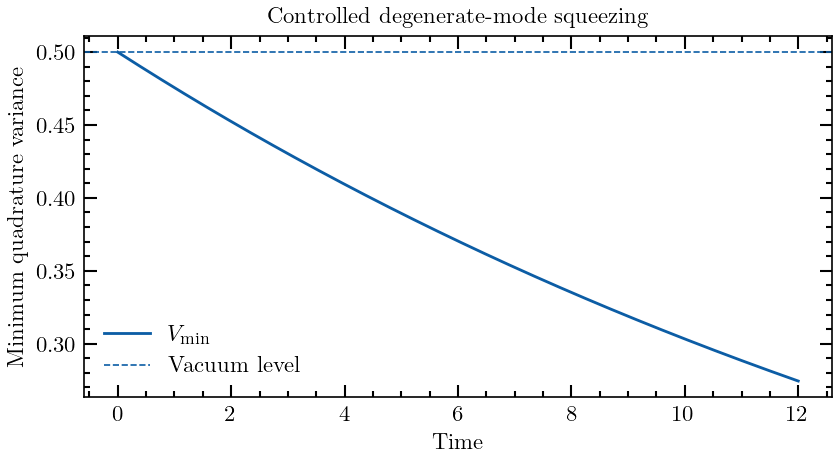

{'minimum_variance': 0.2744058180481348,
 'maximum_mean_photon_number': 0.09273260912110817}

In [35]:
Nc = 24
c = destroy(Nc)
lam = 0.025
s13 = 0.5
Hsq = lam * s13 * (c.dag() ** 2 + c ** 2)
tsq = np.linspace(0, 12, 401)
rsq = sesolve(Hsq, basis(Nc, 0), tsq, options=OPT)

x = (c + c.dag()) / np.sqrt(2)
p = -1j * (c - c.dag()) / np.sqrt(2)


def min_variance(state):
    mx, mp = expect(x, state), expect(p, state)
    vxx = np.real(expect(x * x, state) - mx * mx)
    vpp = np.real(expect(p * p, state) - mp * mp)
    vxp = 0.5 * np.real(expect(x * p + p * x, state) - 2 * mx * mp)
    return np.linalg.eigvalsh([[vxx, vxp], [vxp, vpp]])[0]

Vmin = np.asarray([min_variance(z) for z in rsq.states])
Nph = np.asarray([expect(c.dag() * c, z) for z in rsq.states], dtype=float)

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.35))
fig.subplots_adjust(left=0.14, right=0.985, bottom=0.16, top=0.88)
ax.plot(tsq, Vmin, label=r"$V_{\min}$")
ax.axhline(0.5, lw=0.8, ls="--", label="Vacuum level")
ax.set(xlabel="Time", ylabel="Minimum quadrature variance")
ax.set_title("Controlled degenerate-mode squeezing")
ax.legend(frameon=False, loc="best", handlelength=2.0)
save(fig, "N06_F4")
plt.show()
plt.close(fig)

pd.DataFrame({"t": tsq, "Vmin": Vmin, "mean_photon_number": Nph}).to_csv(DATA / "N06_D15.csv", index=False)
{"minimum_variance": float(Vmin.min()), "maximum_mean_photon_number": float(Nph.max())}


**Figure N06_F4. Controlled degenerate-mode squeezing.** Once an atomic coherence is treated as an externally stabilized control, the effective quadratic field Hamiltonian reduces the minimum quadrature variance below the vacuum level. This field-only calculation does not replace the atom-assisted derivation that precedes it.


## 17.1 Dissipative Raman elimination

If the intermediate level decays, its detuning and linewidth enter through the same non-Hermitian denominator. Let $\Gamma=\gamma_1+\gamma_2$ and
$$
H_{\rm NH}=(-\Delta-\mathrm{i}\Gamma/2)|I\rangle\langle I|.
$$
The effective-operator construction gives
$$
H_{\rm eff}=-\frac12 V_-\left(H_{\rm NH}^{-1}+H_{\rm NH}^{-1\dagger}\right)V_+,
\qquad
L_{r,\rm eff}=L_r H_{\rm NH}^{-1}V_+.
$$
The following calculation compares the full three-level master equation with this complete reduction and with a Hamiltonian-only approximation. The latter misses spontaneous scattering even when the coherent Raman coupling is correct.

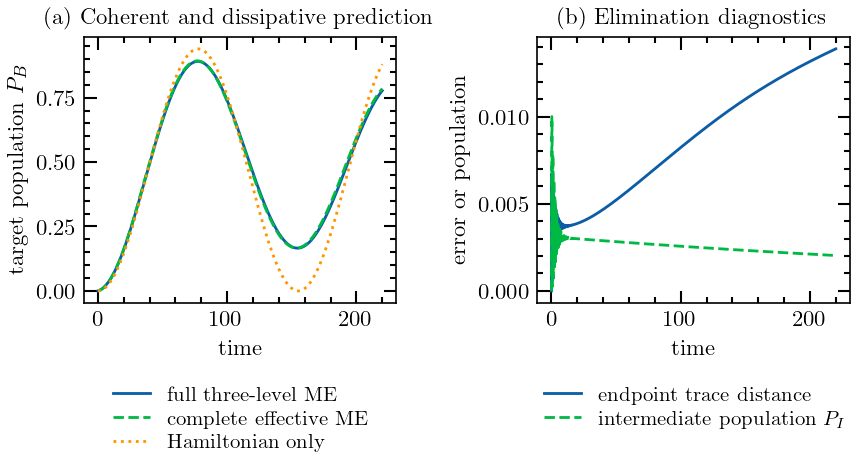

,quantity,value
0,maximum_intermediate_population,0.009998
1,maximum_endpoint_trace_distance,0.013881
2,target_population_rmse_complete,0.006860
3,target_population_rmse_hamiltonian_only,0.079602


In [36]:
Delta_open = 8.0
ga_open, gb_open = 0.45, 0.35
gamma_1, gamma_2 = 0.45, 0.35
Gamma_open = gamma_1 + gamma_2

Vplus_open = ga_open * IL * AL.dag() + gb_open * IL * BL.dag()
Vminus_open = Vplus_open.dag()
H_open = -Delta_open * PIL + Vplus_open + Vminus_open
L1_open = np.sqrt(gamma_1) * AL * IL.dag()
L2_open = np.sqrt(gamma_2) * BL * IL.dag()

denominator_open = -Delta_open - 0.5j * Gamma_open
H_eff_open = (Delta_open / (Delta_open**2 + Gamma_open**2 / 4.0)) * Vminus_open * Vplus_open
L1_eff_open = L1_open * (Vplus_open / denominator_open)
L2_eff_open = L2_open * (Vplus_open / denominator_open)

t_open = np.linspace(0.0, 220.0, 1401)
full_open = qt.mesolve(H_open, AL.proj(), t_open, [L1_open, L2_open], e_ops=[PAL, PIL, PBL], options=OPT)
eff_open = qt.mesolve(H_eff_open, AL.proj(), t_open, [L1_eff_open, L2_eff_open], e_ops=[PBL], options=OPT)
ham_only_open = qt.mesolve(H_eff_open, AL.proj(), t_open, [], e_ops=[PBL], options=OPT)

P_A_open, P_I_open, P_B_open = [np.real(np.asarray(values)) for values in full_open.expect]
P_B_eff_open = np.real(np.asarray(eff_open.expect[0]))
P_B_ham_open = np.real(np.asarray(ham_only_open.expect[0]))
endpoint_distance_open = np.array([
    0.5 * (PEL * rho_full * PEL - rho_eff).norm("tr")
    for rho_full, rho_eff in zip(full_open.states, eff_open.states)
])

open_summary = pd.DataFrame({
    "quantity": ["maximum_intermediate_population", "maximum_endpoint_trace_distance", "target_population_rmse_complete", "target_population_rmse_hamiltonian_only"],
    "value": [
        float(P_I_open.max()),
        float(endpoint_distance_open.max()),
        float(np.sqrt(np.mean((P_B_open - P_B_eff_open) ** 2))),
        float(np.sqrt(np.mean((P_B_open - P_B_ham_open) ** 2))),
    ],
})
pd.DataFrame({
    "time": t_open,
    "P_A_full": P_A_open,
    "P_I_full": P_I_open,
    "P_B_full": P_B_open,
    "P_B_effective_complete": P_B_eff_open,
    "P_B_hamiltonian_only": P_B_ham_open,
    "endpoint_trace_distance": endpoint_distance_open,
}).to_csv(DATA / "N06_D16.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 3.55))
axes[0].plot(t_open, P_B_open, label="full three-level ME")
axes[0].plot(t_open, P_B_eff_open, "--", label="complete effective ME")
axes[0].plot(t_open, P_B_ham_open, ":", label="Hamiltonian only")
axes[0].set(xlabel="time", ylabel=r"target population $P_B$", title="(a) Coherent and dissipative prediction")
axes[0].legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28),
    fontsize=10.0, handlelength=1.8, labelspacing=0.25, borderaxespad=0.0,
)
axes[1].plot(t_open, endpoint_distance_open, label="endpoint trace distance")
axes[1].plot(t_open, P_I_open, "--", label=r"intermediate population $P_I$")
axes[1].set(xlabel="time", ylabel="error or population", title="(b) Elimination diagnostics")
axes[1].legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28),
    fontsize=10.0, handlelength=1.8, labelspacing=0.25, borderaxespad=0.0,
)
fig.subplots_adjust(left=0.12, right=0.985, bottom=0.36, top=0.86, wspace=0.45)
save(fig, "N06_F5")
plt.show()
plt.close(fig)

assert open_summary.loc[0, "value"] < 0.02
assert open_summary.loc[2, "value"] < open_summary.loc[3, "value"]
display(open_summary)

## 18. Method selection and extensions

| Method | Immediate calculation | Main use here |
|---|---|---|
| James-Jerke averaging | harmonic bookkeeping and commutators | fastest map from topology and detuning signs to process sectors |
| Small rotation | $G$ from $[G,H_0]=-V$ | dressing, reconstructed states, and observables |
| Symmetrized projection | virtual paths and endpoint denominators | explicit Hermitian matrix elements |
| Schrieffer-Wolff | block diagonalization by perturbative order | systematic higher-order corrections |
| Exact QuTiP propagation | full tensor-product dynamics | transfer, leakage, entanglement, and cutoff checks |
| Effective-operator method | non-Hermitian excited resolvent | coherent and dissipative terms when the eliminated level is lossy |

Further exercises:

1. Prepare a coherent state in one mode and reconstruct collapse-revival dynamics from Fock-resolved Raman frequencies.
2. Identify the exact dark state of the resonant $\Lambda$ sector and connect it to the STIRAP dark state.
3. Add spontaneous decay from the eliminated level and derive both the Raman Hamiltonian and the induced jump operators.
4. Replace one quantized mode by a classical drive and compare the resulting conditional beam-splitter or squeezing interaction with the fully quantized model.
5. Extend the ladder calculation to unequal photon occupations and verify the local $\sqrt{n}$ scaling of the perturbative parameter.


## 19. References

1. D. F. V. James and J. Jerke, “Effective Hamiltonian theory and its applications in quantum information,” *Can. J. Phys.* **85**, 625 (2007). [DOI](https://doi.org/10.1139/P07-060)
2. A. B. Klimov and L. L. Sánchez-Soto, “Method of small rotations and effective Hamiltonians in nonlinear quantum optics,” *Phys. Rev. A* **61**, 063802 (2000). [DOI](https://doi.org/10.1103/PhysRevA.61.063802)
3. E. Brion, L. H. Pedersen, and K. Mølmer, “Adiabatic elimination in a lambda system,” *J. Phys. A* **40**, 1033 (2007). [DOI](https://doi.org/10.1088/1751-8113/40/5/011)
4. M. Fleischhauer, A. Imamoglu, and J. P. Marangos, “Electromagnetically induced transparency: Optics in coherent media,” *Rev. Mod. Phys.* **77**, 633 (2005). [DOI](https://doi.org/10.1103/RevModPhys.77.633)
5. N. V. Vitanov *et al.*, “Stimulated Raman adiabatic passage in physics, chemistry, and beyond,” *Rev. Mod. Phys.* **89**, 015006 (2017). [DOI](https://doi.org/10.1103/RevModPhys.89.015006)
6. C. C. Gerry and J. H. Eberly, “Dynamics of a Raman coupled model interacting with two quantized cavity fields,” *Phys. Rev. A* **42**, 6805 (1990). [DOI](https://doi.org/10.1103/PhysRevA.42.6805)
7. M. Alexanian and S. K. Bose, “Unitary transformation and the dynamics of a three-level atom interacting with two quantized field modes,” *Phys. Rev. A* **52**, 2218 (1995). [DOI](https://doi.org/10.1103/PhysRevA.52.2218)
8. Y. Wu, “Effective Raman theory for a three-level atom in the $\Lambda$ configuration,” *Phys. Rev. A* **54**, 1586 (1996). [DOI](https://doi.org/10.1103/PhysRevA.54.1586)
9. A. D. Boozer, “Theory of Raman transitions in cavity QED,” *Phys. Rev. A* **78**, 033406 (2008). [DOI](https://doi.org/10.1103/PhysRevA.78.033406)
10. R. M. Serra, C. J. Villas-Bôas, N. G. de Almeida, and M. H. Y. Moussa, “Frequency up- and down-conversions in two-mode cavity quantum electrodynamics,” *Phys. Rev. A* **71**, 045802 (2005). [DOI](https://doi.org/10.1103/PhysRevA.71.045802)
11. F. O. Prado, N. G. de Almeida, M. H. Y. Moussa, and C. J. Villas-Bôas, “Bilinear and quadratic Hamiltonians in two-mode cavity quantum electrodynamics,” *Phys. Rev. A* **73**, 043803 (2006). [DOI](https://doi.org/10.1103/PhysRevA.73.043803)
12. Y. Zhang, B. J. Lester, Y. Y. Gao, L. Jiang, R. J. Schoelkopf, and S. M. Girvin, “Engineering bilinear mode coupling in circuit QED: Theory and experiment,” *Phys. Rev. A* **99**, 012314 (2019). [DOI](https://doi.org/10.1103/PhysRevA.99.012314)
13. Y.-x. Liu *et al.*, “Controllable microwave three-wave mixing via a single three-level superconducting quantum circuit,” *Sci. Rep.* **4**, 7289 (2014). [DOI](https://doi.org/10.1038/srep07289)
14. T. Hönigl-Decrinis *et al.*, “Mixing of coherent waves in a single three-level artificial atom,” *Phys. Rev. A* **98**, 041801(R) (2018). [DOI](https://doi.org/10.1103/PhysRevA.98.041801)
15. C. J. Villas-Boas, K. N. Tolazzi, B. Wang, C. Ianzano, and G. Rempe, “Continuous generation of quantum light from a single ground-state atom in an optical cavity,” *Phys. Rev. Lett.* **124**, 093603 (2020). [DOI](https://doi.org/10.1103/PhysRevLett.124.093603)
16. F. Reiter and A. S. Sørensen, “Effective operator formalism for open quantum systems,” *Phys. Rev. A* **85**, 032111 (2012). [DOI](https://doi.org/10.1103/PhysRevA.85.032111)
17. Z. H. Wang, C. P. Sun, and Y. Li, “Microwave degenerate parametric down-conversion with a single cyclic three-level system in a circuit-QED setup,” *Phys. Rev. A* **91**, 043801 (2015). [DOI](https://doi.org/10.1103/PhysRevA.91.043801)
18. C. W. Gardiner and P. Zoller, *Quantum Noise*, 3rd ed. (Springer, 2004).
19. J. R. Johansson, P. D. Nation, and F. Nori, “QuTiP: An open-source Python framework for the dynamics of open quantum systems,” *Comput. Phys. Commun.* **183**, 1760 (2012). [DOI](https://doi.org/10.1016/j.cpc.2012.02.021)
20. J. R. Johansson, P. D. Nation, and F. Nori, “QuTiP 2: A Python framework for the dynamics of open quantum systems,” *Comput. Phys. Commun.* **184**, 1234 (2013). [DOI](https://doi.org/10.1016/j.cpc.2012.11.019)
21. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,” *Phys. Rep.* **1153**, 1 (2026). [DOI](https://doi.org/10.1016/j.physrep.2025.10.001)

## 20. Numerical validation

The final cell checks the algebraic identities, exact invariants, method equivalence, conversion quality, leakage scale, resonance shifts, physical-frame reconstruction, perturbative slope, cutoff convergence, and degenerate-mode squeezing result.

In [37]:
summary = {
    "qutip": qt.__version__,
    "operator_residual": float(C["residual"].max()),
    "invariant_residual": float(I["norm_[H,N]"].max()),
    "rotation_residual": float(M["rotation_residual"].max()),
    "lambda": lambda_summary,
    "v": v_summary,
    "xi": xi_summary,
    "reconstruction": reconstruction,
    "resonance": resonance,
    "spectral_slope": slope,
    "cutoff_error": float(cutoff["max_difference_from_N4"].max()),
    "minimum_quadrature_variance": float(Vmin.min()),
}

assert summary["operator_residual"] < 1e-10
assert summary["invariant_residual"] < 1e-10
assert summary["rotation_residual"] < 1e-10
assert lambda_summary["max_transfer_exact"] > 0.98
assert v_summary["max_transfer_exact"] > 0.98
assert xi_summary["max_pair_probability_exact"] > 0.98
assert lambda_summary["max_leakage"] < 0.03
assert v_summary["max_leakage"] < 0.03
assert xi_summary["max_leakage"] < 0.03
assert reconstruction["rmse_with_initial_layer"] < reconstruction["rmse_slow"]
assert abs(resonance["lambda_complete_peak"] - resonance["lambda_prediction"]) < 2.1e-3
assert abs(resonance["lambda_cross_peak"]) < 2.1e-3
assert 3.5 < slope < 4.5
assert summary["cutoff_error"] < 1e-8
assert summary["minimum_quadrature_variance"] < 0.5

with open(DATA / "N06_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([
    ("Operator algebra", summary["operator_residual"]),
    ("Excitation invariants", summary["invariant_residual"]),
    ("Method equivalence", summary["rotation_residual"]),
    ("Lambda transfer", lambda_summary["max_transfer_exact"]),
    ("V transfer", v_summary["max_transfer_exact"]),
    ("Xi pair probability", xi_summary["max_pair_probability_exact"]),
    ("Spectral slope", slope),
    ("Cutoff error", summary["cutoff_error"]),
], columns=["check", "value"])


,check,value
0,Operator algebra,0.000000e+00
1,Excitation invariants,0.000000e+00
2,Method equivalence,0.000000e+00
3,Lambda transfer,9.995772e-01
4,V transfer,9.996174e-01
5,Xi pair probability,9.999911e-01
6,Spectral slope,3.984734e+00
7,Cutoff error,1.310063e-14
